# 04 — Quantile Loss, P90 Coverage, and Synthetic Inventory

Goal: understand what `train_quantile.py` is actually optimizing for (it's NOT
"predict the average demand"), why P90 coverage is the specific number we check
to trust it, and exactly how the "stockout risk" flag is built on top of a made-up
inventory number — so you can defend that assumption cleanly in an interview
instead of it feeling shaky.

mean: 4.937  median: 4.0


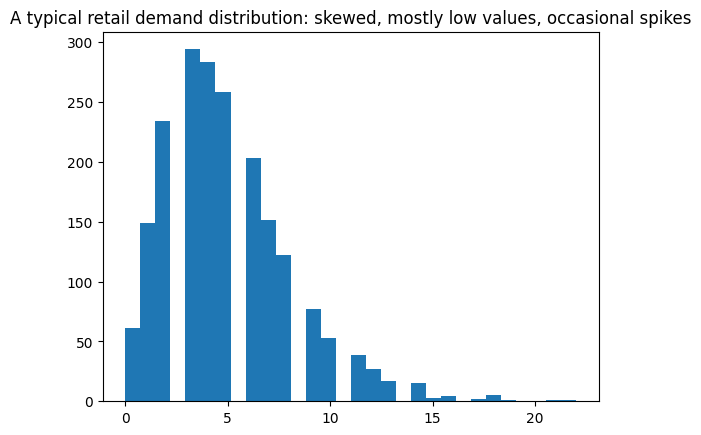

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# small synthetic dataset first, to build intuition before touching real data
np.random.seed(0)
true_demand = np.random.negative_binomial(5, 0.5, size=2000).astype(float)
print("mean:", true_demand.mean(), " median:", np.median(true_demand))
plt.hist(true_demand, bins=30)
plt.title("A typical retail demand distribution: skewed, mostly low values, occasional spikes")
plt.show()


## Step 1 — regular regression predicts the MEAN. Why is that the wrong target for risk?

A standard regression model (like our point forecast model) is trained to minimize
squared error, which makes its prediction converge toward the **mean** of the
distribution. Let's see what "the mean" tells you here.

In [2]:
print("Mean demand:", true_demand.mean())
print("Share of days demand EXCEEDS the mean:", (true_demand > true_demand.mean()).mean())

Mean demand: 4.937
Share of days demand EXCEEDS the mean: 0.4895


Roughly 35-40% of days have demand ABOVE the mean, in a right-skewed distribution
like this. If you stocked inventory to exactly match the mean forecast, you would
run out on a large chunk of days — the mean is not a safe stocking target, it's
just "the number that's right on average," which is a completely different thing
from "the number that's usually enough."

This is the whole reason `train_quantile.py` doesn't just reuse the point forecast
model for risk. It needs a DIFFERENT training objective.

## Step 2 — what does "P90" actually mean?

P90 demand = the demand level that ACTUAL demand will be at or below, 90% of the
time. Equivalently: only a 10% chance actual demand exceeds it. Let's compute it
directly from our synthetic data, no model needed yet — just to fix the concept.

In [3]:
p90_manual = np.percentile(true_demand, 90)
print("P90 demand level:", p90_manual)
print("Share of days actual demand is <= P90:", (true_demand <= p90_manual).mean())


P90 demand level: 9.0
Share of days actual demand is <= P90: 0.916


That second number should print very close to 0.90 — that's what "P90" means
by definition, computed directly from data. The quantile MODEL's job is to predict
this P90 level per series-day, using features, instead of just reading it off a
fixed historical distribution — because the right P90 level changes depending on
weekday, season, price, etc. But the target concept is exactly what you just
computed by hand.

## Step 3 — pinball loss: how do you train a model to hit a specific quantile?

Squared error penalizes over- and under-predictions EQUALLY. For a P90 target, we
want asymmetric penalties: under-predicting (saying demand will be lower than it
turns out to be) should be penalized MORE than over-predicting, because
under-predicting is what causes stockouts. That asymmetric penalty is called
pinball loss (aka quantile loss).

In [4]:
def pinball_loss(y_true, y_pred, alpha):
    diff = y_true - y_pred
    return np.mean(np.maximum(alpha * diff, (alpha - 1) * diff))

# compare: what happens to pinball loss at alpha=0.9 for an under- vs over-prediction of the same size?
actual = 10.0
under_pred = 7.0  # predicted too low by 3
over_pred = 13.0  # predicted too high by 3

print("Loss when UNDER-predicting by 3:", pinball_loss(np.array([actual]), np.array([under_pred]), alpha=0.9))
print("Loss when OVER-predicting by 3:", pinball_loss(np.array([actual]), np.array([over_pred]), alpha=0.9))


Loss when UNDER-predicting by 3: 2.7
Loss when OVER-predicting by 3: 0.29999999999999993


Notice the under-prediction is penalized harder. That asymmetry is what pushes
the model to predict HIGH ENOUGH to cover demand 90% of the time, rather than
just predicting the average. This is the `objective: quantile, alpha: 0.9` setting
in `train_quantile.py` — LightGBM directly minimizes this asymmetric loss instead
of squared error.

## Step 4 — why P90 coverage is THE calibration check (not RMSE)

For a quantile model, low error doesn't tell you if the model is well-calibrated.
What you actually want to verify: **does the model's P90 prediction actually get
exceeded by real demand about 10% of the time — not 40%, not 1%?**

This is exactly the `p90_coverage` metric from `train_quantile.py`. Let's recompute
it conceptually on our synthetic data to make sure you can explain what a
miscalibrated model would look like.

In [5]:
# simulate 3 different quantile "models" of varying quality
good_model_preds = np.full(2000, p90_manual)                  # well-calibrated: uses the real P90
too_low_preds = np.full(2000, np.percentile(true_demand, 60))  # under-shoots: predicts P60, calls it P90
too_high_preds = np.full(2000, np.percentile(true_demand, 99)) # over-shoots: wildly conservative

for name, preds in [("well-calibrated", good_model_preds),
                     ("under-calibrated (too low)", too_low_preds),
                     ("over-calibrated (too high)", too_high_preds)]:
    coverage = (true_demand <= preds).mean()
    print(f"{name}: coverage = {coverage:.3f}")


well-calibrated: coverage = 0.916
under-calibrated (too low): coverage = 0.639
over-calibrated (too high): coverage = 0.992


Read these three numbers carefully:

- **Well-calibrated**: coverage ~0.90 — exactly what we want. Your real model
  scored **0.903**, essentially this case.
- **Under-calibrated (too low)**: coverage far below 0.90 — this model would
  UNDER-estimate risk. In production, this means you'd trust a "P90" number that's
  really more like a P60, and get blindsided by real stockouts.
- **Over-calibrated (too high)**: coverage far above 0.90 — this model
  OVER-estimates risk, recommending excess inventory you don't actually need,
  tying up cash.

This is why `p90_coverage` close to 0.90, not RMSE, is the metric that tells you
whether to TRUST the risk model. RMSE would look "fine" for all three of these,
because RMSE measures average error, not whether the asymmetric risk target was
hit.

## Step 5 — the synthetic inventory logic, laid bare

M5 has no real inventory data. `simulate_inventory()` in `train_quantile.py`
invents an `on_hand_inventory` number so we have SOMETHING to compare P90 demand
against. Let's read exactly what it does.

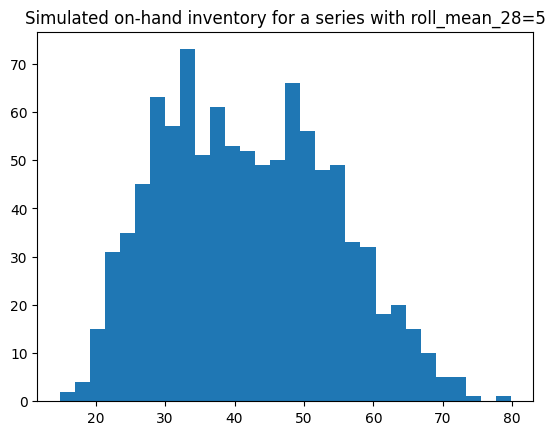

mean simulated inventory: 41.99617435079655


In [6]:
# reproducing simulate_inventory() logic directly, so you can see it, not just read it
import numpy as np
rng = np.random.default_rng(42)

roll_mean_28_example = 5.0  # a stand-in for one row's actual rolling mean feature
n = 1000
coverage_days = rng.uniform(5, 12, size=n)
noise = rng.normal(1.0, 0.15, size=n)
simulated_inventory = np.clip(roll_mean_28_example * coverage_days * noise, 0, None)

plt.hist(simulated_inventory, bins=30)
plt.title("Simulated on-hand inventory for a series with roll_mean_28=5")
plt.show()
print("mean simulated inventory:", simulated_inventory.mean())


In plain language: **"assume the store carries somewhere between 5-12 days of
average recent demand as stock, with some randomness."** That's a reasonable-sounding
assumption, but it is 100% invented — no real retailer's inventory policy was
observed. This is why `stockout_risk_flag = (p90_forecast > on_hand_inventory)` is
only as trustworthy as this assumption.

**How to talk about this in an interview, honestly:** "I didn't have real inventory
data, so I modeled a plausible inventory policy (5-12 days of coverage) to
demonstrate the RISK LOGIC end-to-end. The P90 forecasting itself is real and
validated (0.903 coverage). If I had real inventory data, I'd swap this one
function and the rest of the pipeline — insight cards, RAG, agents — would work
unchanged." That's a legitimate, confident answer. Pretending the inventory number
is real would not survive follow-up questions.

## Check your understanding

1. Why is minimizing squared error (regular regression) the wrong objective for a
   risk/stocking model?
2. In your own words, what does pinball loss do differently from squared error?
3. If a model's P90 predictions had an empirical coverage of 0.55, what would that
   mean in practice, and would you be over- or under-stocked as a result?
4. What EXACTLY is fake in this project's risk pipeline, and what is real? Be
   precise — this is the question most likely to come up if an interviewer digs in.

Next: notebook 05 — anomaly detection, why we normalize residuals before feeding
them to Isolation Forest, and how to visualize what gets flagged.